# 线性回归（二）

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<span style="color:purple">1) 使用pandas库的read_csv()函数(可以参考[pandas的官方文档](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html))将训练数据集'train.csv'和测试数据集'test.csv'载入到Dataframe对象中。</span>

In [28]:
?pd.read_csv

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: '

In [29]:
# Your code here 
file1 = pd.read_csv('train.csv')
df_train = pd.DataFrame(file1)
#读取数据集
#使用函数 pd.read_csv

arr_train = np.array(df_train)
#转化成numpy矩阵
#使用函数 np.array

arr_train

array([[3.60704666e-01, 5.55521539e+00],
       [1.54415346e+00, 9.89094799e+00],
       [2.76704060e+00, 1.39110967e+01],
       [8.16535136e-01, 7.83505417e+00],
       [2.72319697e-01, 5.92490921e+00],
       [6.95010146e-01, 7.46271549e+00],
       [8.24247370e-02, 4.57851162e+00],
       [2.01541232e+00, 1.10609418e+01],
       [4.88964923e-01, 6.24796322e+00],
       [2.33151761e+00, 1.22248394e+01],
       [4.99316650e-01, 6.82276730e+00],
       [2.93206036e+00, 1.39279665e+01],
       [1.63678058e+00, 9.61838868e+00],
       [4.10880624e-01, 5.75266148e+00],
       [1.98564849e+00, 1.13457174e+01],
       [1.14640743e-01, 4.67882850e+00],
       [2.41074536e+00, 1.20510256e+01],
       [2.76277077e+00, 1.37846634e+01],
       [1.16437541e+00, 8.42623547e+00],
       [2.79066087e+00, 1.35375690e+01],
       [5.99142278e-01, 6.91043813e+00],
       [1.79674650e-02, 5.32527941e+00],
       [1.31731753e+00, 9.05937773e+00],
       [2.88622488e+00, 1.35943297e+01],
       [5.113647

<span style="color:purple">2) 假设模型为一元线性回归模型$\hat{y}=wx+b$, 损失函数为$l(w,b)=\frac{1}{2}\sum_{i=1}^m(\hat{y}^{(i)}-y^{(i)})^2$, 其中$\hat{y}^{(i)}$表示第$i$个样本的预测值，$y^{(i)}$表示第$i$个样本的实际标签值, $m$为训练集中样本的个数。求出使得损失函数最小化的参数$w$和$b$。</span>

方法① 

将$l(w,b)$分别对$w$和$b$求导，得到
$$
\frac{\partial l(w,b)}{\partial w}=w\sum_{i=1}^m x_i^2 -\sum_{i=1}^m (y_i-b)x_i,
$$
$$
\frac{\partial l(w,b)}{\partial b}=mb -\sum_{i=1}^m (y_i-wx_i),
$$
令上述两式为零即可得到$w$和$b$的解析解：
$$
w=\frac{\sum_{i=1}^m y_i (x_i-\bar{x})}{\sum_{i=1}^m x_i^2-\frac{1}{m}(\sum_{i=1}^m x_i)^2},
$$
$$
b=\frac{1}{m}\sum_{i=1}^m(y_i-wx_i),
$$
其中$\bar{x}=\frac{1}{m}\sum_{i=1}^m x_i$为$x$的均值。



In [30]:
?np.sum

Signature:      
np.sum(
    a,
    axis=None,
    dtype=None,
    out=None,
    keepdims=<no value>,
    initial=<no value>,
    where=<no value>,
)
Call signature:  np.sum(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function sum at 0x7f10f39323e0>
File:            ~/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py
Docstring:      
Sum of array elements over a given axis.

Parameters
----------
a : array_like
    Elements to sum.
axis : None or int or tuple of ints, optional
    Axis or axes along which a sum is performed.  The default,
    axis=None, will sum all of the elements of the input array.  If
    axis is negative it counts from the last to the first axis. If
    axis is a tuple of ints, a sum is performed on all of the axes
    specified in the tuple instead of a single axis or all the axes as
    before.
dtype : dtype, optional
    The type of the returned array and of the accumulator in which the
    elements are summed. 

In [31]:
# Your code here
#使用函数 np.sum
# 需要求yi * (xi-x_mean)， xi^2, x_mean
arr_square = arr_train[:, 0] ** 2 # xi^2
x_mean = np.mean(arr_train, axis=0)[0] # x的均值
arr_numerator = arr_train[:, 1] * (arr_train[:, 0] - x_mean) # yi * (xi - x_mean)， 分子
omega = np.sum(arr_numerator) / (np.sum(arr_square) - np.sum(arr_train, axis = 0)[0] ** 2 / arr_train.shape[0] )# w
mean_dis = arr_train[:, 1] - omega * arr_train[:, 0] # 平均偏移量 b
b = np.sum(mean_dis) / arr_train.shape[0] # b
print(omega, b)

3.041478869915313 4.906073659305301


方法② 梯度下降法。手动实现梯度下降法(不使用机器学习框架，如PyTorch、TensorFlow等)来进行模型的训练。算法步骤如下：1.初始化模型参数$w$和$b$的值；2.在负梯度的方向上更新参数(批量梯度下降、小批量随机梯度下降或者随机梯度下降均可)，并不断迭代这一步骤，更新公式(以小批量随机梯度下降为例)可以写成：$$w\gets w-\frac{\eta}{\left|B\right|}\sum_{i\in{B}}x^{(i)}(wx^{(i)}+b-y^{(i)}),$$ 和$$b\gets b-\frac{\eta}{\left|B\right|}\sum_{i\in{B}}(wx^{(i)}+b-y^{(i)}),$$ 其中$\eta$表示学习率,$B$表示每次迭代中随机抽样的小批量，$\left|B\right|$则表示$B$中的样本数量。3. 终止条件为迭代次数达到某一上限或者参数更新的幅度小于某个阈值。

In [32]:
# Your code here
#使用 for循环，函数 np.sum等
l_rate = 0.1
n_iter = 1000
data_size = arr_train.shape[0]
omega_2 = 0
b_2 = 0
for i in range(n_iter):
    temp = omega_2
    omega_2 = omega_2 -  np.sum(arr_train[:, 0] * (arr_train[:, 0] * omega_2 + b_2 - arr_train[:, 1]), axis = 0) * l_rate / data_size
    b_2 = b_2 - np.sum(arr_train[:, 0] * temp + b_2 - arr_train[:, 1]) * l_rate / data_size
print(omega_2, b_2)

3.041478871472472 4.906073656421955


方法③ 

用矩阵表示，假设数据集有$m$个样本，特征有$n$维$。X=\left[ \begin{matrix} x_{11} & x_{12} & \cdots & x_{1n} & 1 \\
                         x_{21} & x_{22} & \cdots & x_{2n} & 1 \\
                         \vdots & \vdots &      & \vdots & \vdots \\
                         x_{m1} & x_{m2} & \cdots & x_{mn} & 1 \end{matrix} \right]$,
        实际标签$Y=\left[ \begin{matrix} y_{1} \\
                         y_{2} \\
                         \vdots \\
                         y_{m}\end{matrix} \right]$,
        参数$B=\left[ \begin{matrix} w_{1} \\
                         w_{2} \\
                         \vdots \\
                         w_{n} \\
                         b\end{matrix} \right]$，则解析解为$B^*=(X^T X)^{-1}X^T Y$。推导过程可参考[这篇文章](https://zhuanlan.zhihu.com/p/74157986)。

In [33]:
# Your code here
#使用函数 np.c_ np.ones np.linalg.inv
# 此数据集有160个样本, 特征有1维
# X = np.hstack((arr_train[:, 0], np.ones(arr_train.shape[0], 1)))
X = np.hstack((arr_train[:, 0].reshape(-1,1), np.ones((arr_train.shape[0], 1))))
Y = arr_train[:, 1]
B = np.linalg.inv(X.T @ X) @ X.T @ Y
omega_3 = B[0]
b_3 = B[1]
print(B)

[3.04147887 4.90607366]


<span style="color:purple">3) 使用求解出来的线性回归模型对测试数据集'test.csv'进行预测，输出可视化结果（比如用seaborn或者matplotlib等可视化库来画出测试数据的散点图以及训练好的模型函数图像）。</span>

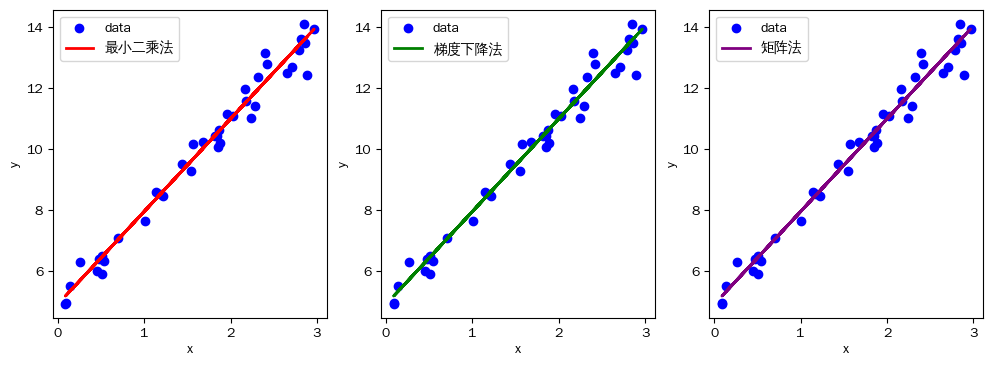

In [34]:
# Your code here
#A=np.array([[1,2,3],[4,5,6],[7,8,9]])
#x = A[0, :] #从一个矩阵中提取出一行作为一个向量
#y1 = np.array([2, 3, 5])
#plt.plot(x, y1) #画出折线图
#y2 = np.array([2.5, 2.8, 5.3])
#plt.plot(x, y2, '.') #画出散点图
#plt.show()
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
file_test = pd.read_csv('test.csv')
df_test = pd.DataFrame(file_test)
arr_test = np.array(df_test)
x = arr_test[:, 0]
y = arr_test[:, 1]
y1 = omega * x + b
y2 = omega_2 * x + b_2
y3 = omega_3 * x + b_3
# fig, (ax1,ax2,ax3) = plt.Subplot(1,3, figsize=(15,5))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.scatter(x, y, color="blue", label="data")
ax2.scatter(x, y, color="blue", label="data")
ax3.scatter(x, y, color="blue", label="data")
# 三条拟合直线
ax1.plot(x, y1, color='red', label="最小二乘法", linewidth=2)
ax2.plot(x, y2, color='green', label="梯度下降法", linewidth=2)
ax3.plot(x, y3, color='purple',label="矩阵法", linewidth=2)

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax1.legend()
ax2.legend()
ax3.legend()
plt.show()


In [35]:
l1 = np.sum((y - y1) ** 2) / y.shape[0]
l2 = np.sum((y - y2) ** 2) / y.shape[0]
l3 = np.sum((y - y3) ** 2) / y.shape[0]
print(l1, l2, l3)

0.170268086968883 0.17026808696995938 0.17026808696888246


<span style="color:purple">4) 在训练数据集'train2.csv'上求一个三元线性回归模型$\hat{y}=w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3$的使得损失函数$l(w_0,w_1,w_2,w_3)=\frac{1}{2}\sum_{i=1}^m(\hat{y}^{(i)}-y^{(i)})^2$最小的参数$w_0,w_1,w_2$以及$w_3$。并在测试数据集'test2.csv'上进行预测，输出预测结果的均方误差$MSE(\hat{y},y)=\frac{1}{n}\sum^n_{i=1}(y^{(i)}-\hat{y}^{(i)})^2$, $n$为测试集中样本个数。</span>

方法① 同2)中的方法③。

方法② 类似2)中的方法②。算法步骤如下：1.初始化模型参数$w_0,w_1,w_2,w_3$的值；2.在负梯度的方向上更新参数(批量梯度下降、小批量随机梯度下降或者随机梯度下降均可)，并不断迭代这一步骤，更新公式(以小批量随机梯度下降为例)可以写成：$$w_j\gets w_j-\frac{\eta}{\left|B\right|}\sum_{i\in{B}}x_j^{(i)}(w_0 + w_1 x_1^{(i)}+w_2 x_2^{(i)}+w_3 x_3^{(i)}-y^{(i)}), j=0,1,2,3,$$ 其中$x_0^{(i)}=1$， 其中$\eta$表示学习率,$B$表示每次迭代中随机抽样的小批量，$\left|B\right|$则表示$B$中的样本数量。3. 终止条件为迭代次数达到某一上限或者参数更新的幅度小于某个阈值。

In [36]:
# Your code here
file1 = pd.read_csv('train2.csv')
df_train = pd.DataFrame(file1)
train_arr = np.array(df_train)
# 矩阵法
X = np.hstack((train_arr[:,0:3], np.ones((train_arr.shape[0], 1))))
Y = train_arr[:, 3] 
B = np.linalg.inv(X.T @ X) @ X.T @ Y
omega_4 = B[0:3]
b_4 = B[3]
print(B)

[1.00723001 2.00339371 3.01025624 5.94254393]


In [37]:
# omega - (4,) b - () omega * x 
l_rate = 0.01
n_iter = 9000
data_size = train_arr.shape[0]
omega_5 = np.zeros(4)
Y = train_arr[:, 3]
train_arr = np.hstack((np.ones((train_arr.shape[0], 1)), train_arr[:,0:3]))
for i in range(n_iter):
    bias = train_arr @ omega_5 - Y
    grad = (train_arr.T @ bias) / data_size # (4,)
    omega_5 = omega_5 - l_rate * grad
print(omega_5)

[5.94171807 1.00732908 2.00349462 3.01036272]


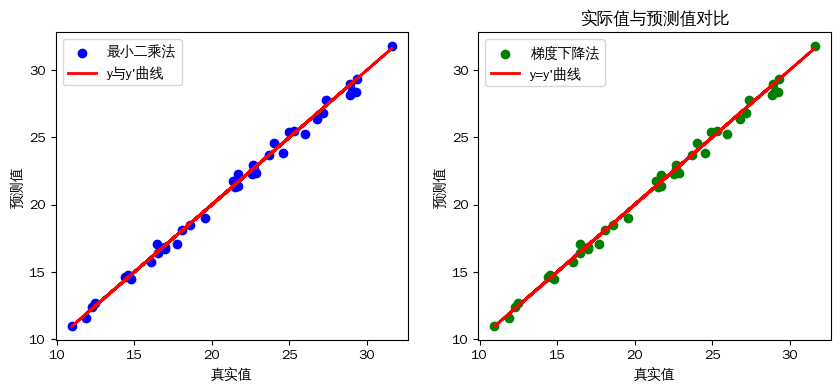

In [38]:
file_test = pd.read_csv('test2.csv')
df_test = pd.DataFrame(file_test)
test_arr = np.array(df_test)
x1 = test_arr[:, 0]
x2 = test_arr[:, 1]
x3 = test_arr[:, 2]
y = test_arr[:, 3]
y1 = omega_4[0] * x1 + omega_4[1] * x2 + omega_4[2] * x3 + b_4
y2 = omega_5[1] * x1 + omega_5[2] * x2 + omega_5[3] * x3 + omega_5[0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(y, y1, color="blue", label="最小二乘法")
ax1.plot(y,y, color='red', label='y与y\'曲线', linewidth=2)
ax2.scatter(y, y2, color="green", label="梯度下降法")
ax2.plot(y,y, color='red', label='y=y\'曲线', linewidth=2)
ax1.set_xlabel("真实值")
ax1.set_ylabel("预测值")
ax2.set_xlabel("真实值")
ax2.set_ylabel("预测值")
ax1.legend()
ax2.legend()
plt.title("实际值与预测值对比")
plt.show()

In [39]:
l4 = np.sum((y - y1) ** 2) / y.shape[0]
l5 = np.sum((y - y2) ** 2) / y.shape[0]
print(l4, l5)

0.16537691128176946 0.1653678705896775
